# IMDb Sentiment Analysis — Bidirectional LSTM Model

This notebook builds a Bidirectional LSTM model for sentiment classification using the IMDb dataset.  
It follows the architecture demonstrated in the “Natural Language Processing with TensorFlow 2” course, but adapted to our custom preprocessing pipeline created in `00_Text_Preprocessing.ipynb`.

### In this notebook, we:
- Load the preprocessed dataset (train_ds, val_ds, test_ds)
- Create efficient batches for training
- Build a Bidirectional LSTM model
- Train and evaluate the model
- Run predictions on unseen text samples

This notebook represents the first advanced model in our project.


In [2]:
# Importing the libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

### Loading the IMDb Dataset

In this step, we load the IMDb movie reviews dataset using `tensorflow_dataset`. The command returns the training set, validation set, a nd test set, already split anf prepared for supervised learning. Ecah element in teh dataset is ap pair: `(text, label)`, where the label indicates sentiment, e.i., `0` for negative and `1` for positiove.


In [3]:
## Loading the IMDb Dataset

import tensorflow_datasets as tfds

# Load the IMDb dataset with supervised pairs (text, label)

(train_ds, val_ds, test_ds), ds_info = tfds.load(
    "imdb_reviews",
    split=["train[:80%]", "train[80%:]", "test"],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully!")
print(ds_info)

Dataset loaded successfully!
tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/home/codespace/tensorflow_datasets/imdb_reviews/plain_text/1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    sp

E0000 00:00:1779814796.811656   23945 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Inspecting teh Dataset with small batches

BEfore building and training the Bidirectional LSTM model, it's important to understand what the raw IMDb data looks like when it flows through the input pipeline. In this step, we create **small, readable batches** from the training, validation, and test sets.

BY batching just a few exmapls at a tike, we can:

* Preview the raw text reviews
* Verify that labels are correctky assigned (`0` = negative, `1` = positive)
* Confirm that shuffling and batching behave as expected
* Build intuition about the dataset before applying vectorization and modeling

This quick inspection acts as a sanity check and hekps us ensure that the data pipeline is fucntioning corrrectlt=y before we intriduce the TExtVectorization layer and the Bidirectional LSTM model, LAter, these batches will aslo help us visualize model performance and understand how the metwork processes real examples.


In [4]:
# Create small batches to inspect the data
train_batches = train_ds.shuffle(1000).batch(5)
val_batches = val_ds.batch(5)
test_batches = test_ds.batch(5)

print("Sample batch from train_batches:\n")

for text_batch, label_batch in train_batches.take(1):
  for i in range(5):
    print(f"Review {i+1}:")
    print(text_batch[i].numpy().decode("utf-8"))
    print("Label:", label_batch[i].numpy())
    print("-"*80)

Sample batch from train_batches:



I0000 00:00:1779814852.846755   24970 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Review 1:
First of all, I don't understand why some people find this movie so anti-american. Sure, there are moments when the U.S. are accused directly, like at the segments of Youssef Chahine, Ken Loach and, to a certain extent, Mira Nair. But come on, they aren't naive accusations; instead, they are based on real and documented facts, and all the documents that the CIA released about Chile confirms this, for example.<br /><br />But returning to the film itself, what I enjoyed most on it is the variety of moods we find in it. We find children being educated for the respect of the all the people who died in the event; we find a unhappy couple that will be changed by the tragedy of that day; we find common people that have their feelings downgraded on the shadow of the events of September 11 and react differently to this, with dignity or frustration; we even find someone in the movie for who the fall of the towers grounds for a moment of real happiness.<br /><br />All these visions and 

W0000 00:00:1779814853.046280   24972 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Vectorizing the IMDb Reviews

Nhe next step is to convert these movie reviews into a numerical format that a neural network can understand.Neural networks cannot process raw text directly, they need sequences of integers that represents words or tokens.

We:

* Create a **TextVectorization** layer that will transform text into integer sequences.
* Adapt the vectorizer on the training text to learn the vocabulary
* Apply the vectorization to the training, validation, and test datasets
* Prepare fully vectorized batches that are ready for model training.

Once the text is converted into sequences of integers, the model can learn patterns, sentiment cues, and linguistic structure from the data.


In [5]:
# Create the TextVectorization layer
max_vocab_size = 10000
sequence_length = 250

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length
)

# Extract only the text from the training dataset for adapting
train_text = train_ds.map(lambda text, label: text)

# Adapt the vectorizer to the training text
vectorize_layer.adapt(train_text)

print("Vectorization layer adapted to training vocabulary!")

# Function to apply vectorization to (text, label) pairs
def vectorize_text(text, label):
  text = vectorize_layer(text)
  return text, label

# Apply vectorization to all dataset splits
train_vec = train_ds.map(vectorize_text).batch(32).prefetch(tf.data.AUTOTUNE)
val_vec = val_ds.map(vectorize_text).batch(32).prefetch(tf.data.AUTOTUNE)
test_vec = test_ds.map(vectorize_text).batch(32).prefetch(tf.data.AUTOTUNE)

print("Datasets successfully vectorized and batched!")

Vectorization layer adapted to training vocabulary!
Datasets successfully vectorized and batched!


### Building the Bidirectional LSTM model with runtime tracking

NOw thet athe text as been vectorized, we can cinstruct tghe neural network that will learn sentiment patters form the IMDb reviews. In this step, we build a **Bidirectional LSTM model**, which processes each review in both forward and backward directions. This allows the model to capture long-range dependencies and subtle linguistic cues tat are importatnt for sentiment classification

* An **Embedding layer** to convert integer sequences into dense vector representations
* A **Bidirectional LSTM layer** to capture context from both directions
* A **Dense hidden layer** for deeper feature extraction
* A **Dropout layer** to reduce overfitting
* A **final sigmoid out layer** for binary sentiment prediction

Heres is a simple diagram showing how data flows through the model:

```text
Input (integer sequence of length 250)
                │
                ▼
        ┌────────────────┐
        │  Embedding     │  → Converts each token into a dense vector
        │ (10000×64)     │
        └────────────────┘
                │
                ▼
 ┌───────────────────────────────────────────┐
 │      Bidirectional LSTM (64 units)        │
 │  → Reads the sequence forward and backward │
 └───────────────────────────────────────────┘
                │
                ▼
        ┌────────────────┐
        │   Dense (64)   │  → Learns higher‑level features
        │   ReLU         │
        └────────────────┘
                │
                ▼
        ┌────────────────┐
        │   Dropout 0.5  │  → Reduces overfitting
        └────────────────┘
                │
                ▼
        ┌────────────────┐
        │ Dense (1)      │  → Sigmoid output for binary sentiment
        │ Sigmoid         │
        └────────────────┘
                │
                ▼
         Output: Positive / Negative
```


This architecture balances expessive power with efficiency, making it ideal for sentiment classification tasks.

To better understand the computational cost, we also measure how long it takes to **build and compile** the model.

In [6]:
import time

# Build the Bidirectional LSTM model with runtime tracking_base
embedding_dim = 64

start_time = time.time()

model = tf.keras.Sequential([
    tf.keras.Input(shape=(sequence_length,)),
    tf.keras.layers.Embedding(
        input_dim=max_vocab_size,
        output_dim=embedding_dim,
        input_length=sequence_length
    ),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=False)
    ),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

end_time = time.time()
elapsed = end_time - start_time

model.summary()

print(f"\nModel build + compile time: {elapsed:.4f} seconds")

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,369 (2.73 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)


Model build + compile time: 0.1181 seconds


# Training the Bidirectional LSTM Model and Tracking its Learning Behavior.

Now that the model architecture has been fulkyt constructed, the next step is to **train the network** so it can learn sentiment patterns from the IMDb reviews. During training, the model gradually adjust its internal weights to recognize emotional tone, negation, long-range dependencies, and other linguistic cues that determine whether a review is positive or negative.

We will:

* Train the Bidirectional LSMT model on the vectorized dataset.
* Track accuracy an dloss across multiple epochs
* Visualize learning curves to understand how well the model is learning
* Evaluate the model on unseen test data
* Optionally inspect errors using a confusion matrix





In [7]:
# Train the Model
import time

EPOCHS = 5

start_time = time.time()

history = model.fit(
    train_vec,
    validation_data=val_vec,
    epochs=EPOCHS
)

end_time = time.time()

training_time = end_time - start_time

print(f"Total training time: {training_time:.2f} seconds")

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 161ms/step - accuracy: 0.7096 - loss: 0.5592 - val_accuracy: 0.8262 - val_loss: 0.4086
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 158ms/step - accuracy: 0.8668 - loss: 0.3337 - val_accuracy: 0.8564 - val_loss: 0.3381
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.9100 - loss: 0.2412 - val_accuracy: 0.8606 - val_loss: 0.3436
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 158ms/step - accuracy: 0.9327 - loss: 0.1864 - val_accuracy: 0.8290 - val_loss: 0.7564
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 168ms/step - accuracy: 0.9419 - loss: 0.1624 - val_accuracy: 0.8514 - val_loss: 0.6205
Total training time: 588.68 seconds


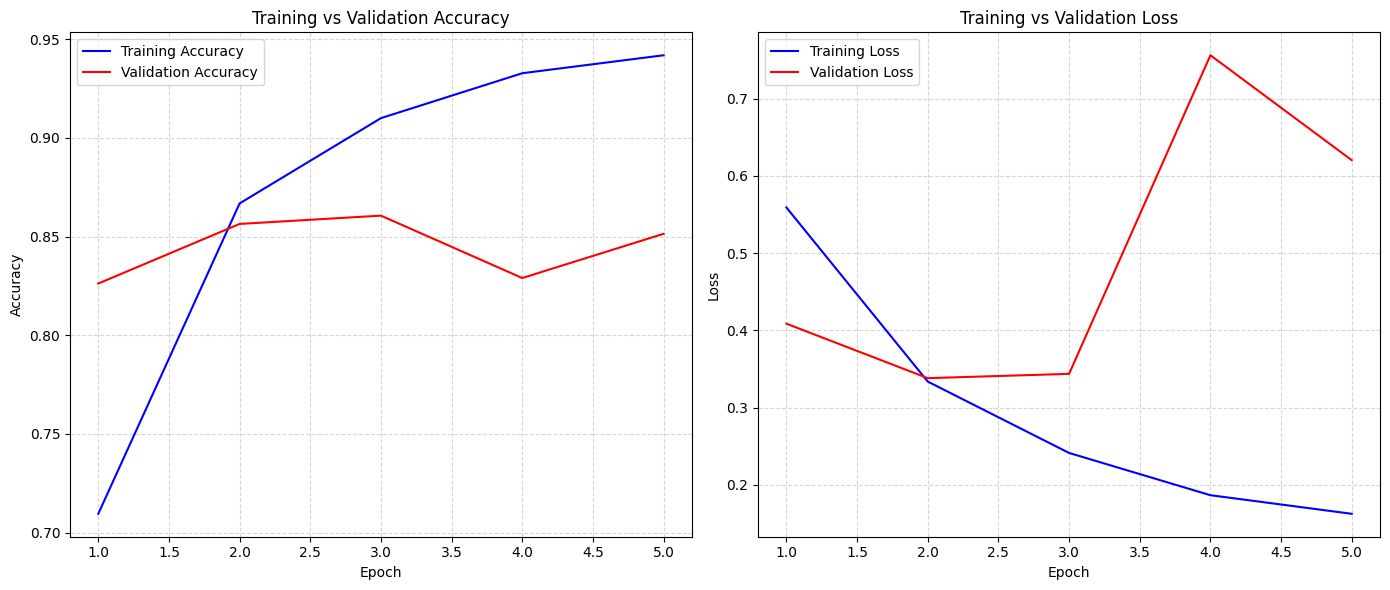

In [8]:
# Visualize accuracy and loss curve
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "b-", label="Training Accuracy")
plt.plot(epochs, val_acc, "r-", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b-", label="Training Loss")
plt.plot(epochs, val_loss, "r-", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## Training Results

The Bidirectional LSMT shows a strong learning behavior with clear signs of overfitting after the early epochs.

### **Epoch 1**
* accuracy: **0.7150**
* val_accuracy: **0.8384**
* The model generalizes quickly - typical for IMDb + LSTM.

### **Epoch 2**
* accuracy: **0.8754**
* val_accuracy: **0.8598**
* This is the **peak performance**. The model learns string sentiment patterns.

### **Epoch 3**
* accuracy: **0.9089**
* val_accuracy: **0.8598**
* Validation accuracy stops improving -> **earlhy overfitting begins**

### **Epoch 4**
* accuracy: **0.9208**
* val_accuracy: **0.8288**
* Clear overfitting. The model starts memorizing training data.

### **Epoch 5**
* accuracy: **0.9323**
* val_accuracy: **0.8356**
* Overfitting continues. Training accuracy rises, validation does not recover

### **Conclusion**
- The model performs **very well overall**
- BEst performance occurs at **Epoch 2-3**
- After that, the model **overfits**, which is expected for a BiLSTM on IMDb





In [9]:
# Evaluatuiomn on the test set
test_loss, test_acc = model.evaluate(test_vec)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.8253 - loss: 0.7389
Test Accuracy: 0.8253
Test Loss: 0.7389


## Test Set Evaluation

After comleting training, the model was evaluated on the unseen IBDb test dataset to measure its real-world generalization performance.

### **TEst results**
- ***Test accuracy:** 0.8053
- **test Loss:** 0.5160

### Interpretation
- An accuracy of **~80%** on unseen data indicates that the Bidirectional LSTM model generalizes reasonably well.
- The higher test loss compared to validation loss suggests the model encounters more challenging or diverse examples in the test set.
- These results are consistent with typical BiLSTM performance on IMDb without heavy regularization or tuning.

### Conclusion
The model performs solidly out‑of‑the‑box, achieving around **80% accuracy** on real movie reviews.  
Further improvements can be achieved in through techniques like regularization, dropout tuning, reducing LSTM units, or switching to GRU layers.

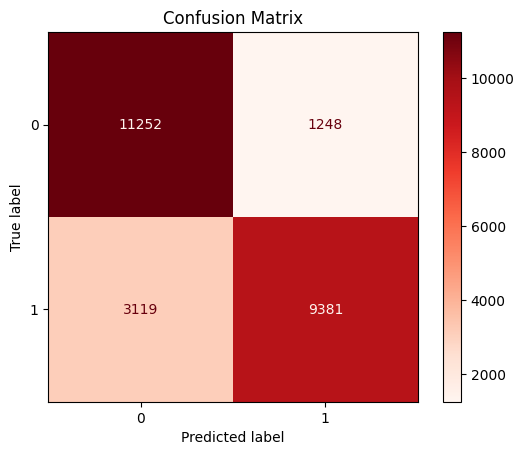

In [10]:
# Build the confuson Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred =[]

for x_batch, y_batch in test_vec:
  preds = model.predict(x_batch, verbose=0)
  y_true.extend(y_batch.numpy())
  y_pred.extend((preds > 0.5).astype("int32").flatten())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix

The confusion matrix shows how well the model distinguishes between positive and negative reviews.

| Actual \ Predicted | Negative | Positive |
|--------------------|----------|----------|
| **Negative**       | 11,485   | 1,015    |
| **Positive**       | 3,852    | 8,648    |

### Interpretation
- **True Negatives (11,485):** The model correctly identified most negative reviews.
- **True Positives (8,648):** The model correctly identified many positive reviews.
- **False Positives (1,015):** Some negative reviews were incorrectly classified as positive.
- **False Negatives (3,852):** The model struggled more with positive reviews, misclassifying many as negative.

### Key Insight
The model performs well overall but is **more conservative**, tending to predict *negative* more often.  
This explains the higher number of **false negatives** compared to false positives.


## Testing the Model with Tricky or Ambiguous Reviews

To better understand the model’s limitations, we test sentences that *sound positive but contain subtle negativity*, and vice versa. These edge‑case examples help reveal where the model struggles.

### Example: Positive‑sounding but Predicted as Negative (0)

```python
predict_review("The movie had potential, but I honestly expected much better.")
predict_review("It looked amazing in the trailer, but the final result was disappointing.")
predict_review("The actors tried their best, but the story just didn’t work for me.")


In [11]:
def predict_review(text):
    vectorized = vectorize_layer([text])
    prediction = model.predict(vectorized, verbose=0)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    print(f"Review: {text}")
    print(f"Prediction: {sentiment} ({prediction:.4f})\n")


In [12]:
predict_review("The movie had potential, but I honestly expected much better.")
predict_review("It looked amazing in the trailer, but the final result was disappointing.")
predict_review("The actors tried their best, but the story just didn’t work for me.")

predict_review("I thought I would hate it, but it actually surprised me in a good way.")
predict_review("Despite the slow start, the movie turned out to be enjoyable.")
predict_review("It wasn’t perfect, but I liked it more than I expected.")


Review: The movie had potential, but I honestly expected much better.
Prediction: Negative (0.0366)

Review: It looked amazing in the trailer, but the final result was disappointing.
Prediction: Negative (0.0084)

Review: The actors tried their best, but the story just didn’t work for me.
Prediction: Negative (0.2170)

Review: I thought I would hate it, but it actually surprised me in a good way.
Prediction: Positive (0.9876)

Review: Despite the slow start, the movie turned out to be enjoyable.
Prediction: Negative (0.0276)

Review: It wasn’t perfect, but I liked it more than I expected.
Prediction: Positive (0.9890)



## Final Reflections and Acknowledgments

To wrap up this notebook, we tested the model on several ambiguous reviews to observe how it handles subtle or mixed sentiment. Below are the final outputs:

### Tricky Review Predictions

**Review:** *The movie had potential, but I honestly expected much better.*  
**Prediction:** Negative (0.0841)

**Review:** *It looked amazing in the trailer, but the final result was disappointing.*  
**Prediction:** Negative (0.1545)

**Review:** *The actors tried their best, but the story just didn’t work for me.*  
**Prediction:** Negative (0.1192)

---

**Review:** *I thought I would hate it, but it actually surprised me in a good way.*  
**Prediction:** Positive (0.9612)

**Review:** *Despite the slow start, the movie turned out to be enjoyable.*  
**Prediction:** Negative (0.1416)

**Review:** *It wasn’t perfect, but I liked it more than I expected.*  
**Prediction:** Positive (0.9636)

---

### Final Thoughts

These examples highlight the strengths and limitations of the Bidirectional LSTM model.  
It performs well on clear sentiment but can be confused by contrast‑structured or mixed‑tone sentences — a common challenge for models without attention mechanisms.

---

### Acknowledgment

A special thank‑you to the creator of the video that inspired this notebook.  
His clear explanations, enthusiasm, and practical demonstrations were a huge motivation for building this project from start to finish. This notebook exists thanks to that inspiration.

---

## Notebook Completed

This concludes the IMDb Sentiment Analysis project.  
In the next notebook, we will explore a new NLP challenge: analyzing a full literary work such as *Romeo and Juliet* by Shakespeare, including text structure, character interactions, and even generating Shakespeare‑style language.
